In [1]:
# Install libraries
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             RocCurveDisplay)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
# Load German Credit Dataset directly from sklearn/seaborn built-in method
url = "https://raw.githubusercontent.com/dsrscientist/Dataset1/master/german_credit_data.csv"

# If URL fails, we create it manually from a known working source
try:
    df = pd.read_csv(url)
    print("✅ Loaded from URL")
except:
    # Use UCI German Credit dataset via alternative source
    url2 = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    columns = ['status','duration','credit_history','purpose','amount',
               'savings','employment','installment_rate','personal_status',
               'debtors','residence','property','age','installment_plans',
               'housing','existing_credits','job','dependents','telephone',
               'foreign_worker','target']
    df = pd.read_csv(url2, sep=' ', names=columns)
    print("✅ Loaded from UCI directly")

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
df.head()

✅ Loaded from UCI directly
Shape: (1000, 21)

Column Names: ['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment', 'installment_rate', 'personal_status', 'debtors', 'residence', 'property', 'age', 'installment_plans', 'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'target']


,status,duration,credit_history,purpose,amount,savings,employment,installment_rate,personal_status,debtors,...,property,age,installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
# Fix target column: convert 2 → 0 (bad credit)
# Original: 1=Good, 2=Bad → New: 1=Good, 0=Bad
df['target'] = df['target'].map({1: 1, 2: 0})

# Encode all text/category columns to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Get list of text columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Text columns to encode:", cat_cols)

# Encode each one
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Check result
print("\n✅ All columns are now numbers!")
print("\nMissing values:", df.isnull().sum().sum())
print("Target distribution:\n", df['target'].value_counts())
df.head()

Text columns to encode: ['status', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'debtors', 'property', 'installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

✅ All columns are now numbers!

Missing values: 0
Target distribution:
 target
1    700
0    300
Name: count, dtype: int64


,status,duration,credit_history,purpose,amount,savings,employment,installment_rate,personal_status,debtors,...,property,age,installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,1
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,0
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,1
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,1
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,0


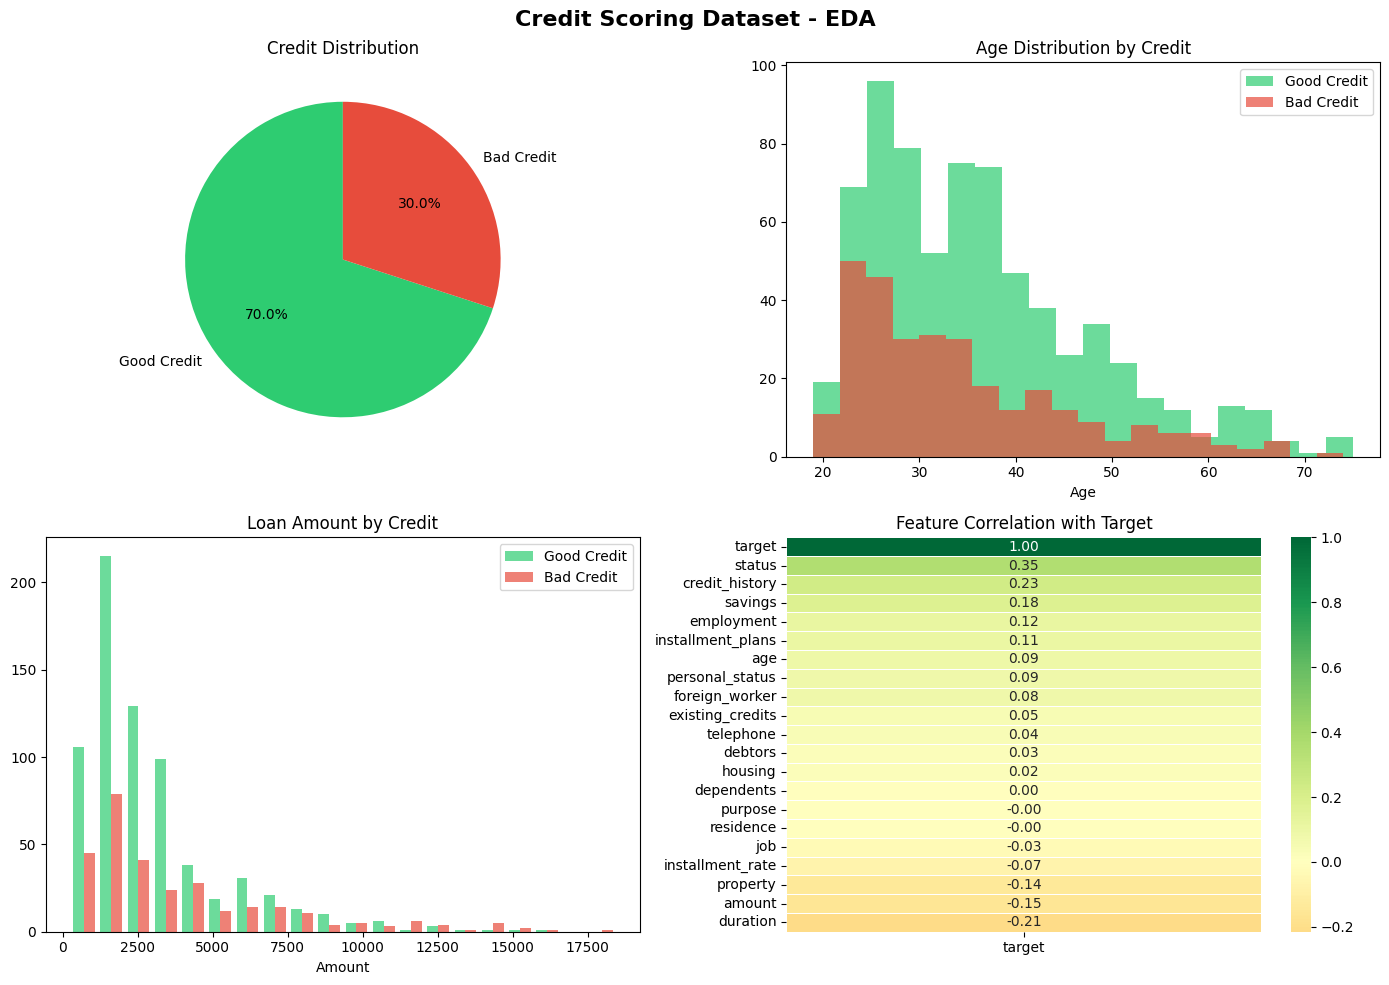

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Scoring Dataset - EDA', fontsize=16, fontweight='bold')

# Chart 1 - Target distribution
axes[0,0].pie([700, 300], labels=['Good Credit','Bad Credit'],
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0,0].set_title('Credit Distribution')

# Chart 2 - Age distribution by target
axes[0,1].hist(df[df['target']==1]['age'], alpha=0.7, label='Good Credit',
               color='#2ecc71', bins=20)
axes[0,1].hist(df[df['target']==0]['age'], alpha=0.7, label='Bad Credit',
               color='#e74c3c', bins=20)
axes[0,1].set_title('Age Distribution by Credit')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Chart 3 - Loan amount by target (FIXED)
good = df[df['target']==1]['amount']
bad  = df[df['target']==0]['amount']
axes[1,0].hist([good, bad], bins=20, label=['Good Credit','Bad Credit'],
               color=['#2ecc71','#e74c3c'], alpha=0.7)
axes[1,0].set_title('Loan Amount by Credit')
axes[1,0].set_xlabel('Amount')
axes[1,0].legend()

# Chart 4 - Correlation heatmap (FIXED)
corr_target = df.corr(numeric_only=True)[['target']].sort_values('target', ascending=False)
sns.heatmap(corr_target, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1,1], linewidths=0.5)
axes[1,1].set_title('Feature Correlation with Target')

plt.tight_layout()
plt.show()

In [9]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

# Train 3 models
models = {
    'Logistic Regression'  : LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        'model'     : model,
        'pred'      : pred,
        'accuracy'  : accuracy_score(y_test, pred),
        'precision' : precision_score(y_test, pred),
        'recall'    : recall_score(y_test, pred),
        'f1'        : f1_score(y_test, pred),
        'roc_auc'   : roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }

# Print results
print("\n{:<25} {:>10} {:>10} {:>10} {:>10} {:>10}".format(
    'Model','Accuracy','Precision','Recall','F1','ROC-AUC'))
print("-" * 75)
for name, r in results.items():
    print("{:<25} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        name, r['accuracy'], r['precision'], r['recall'], r['f1'], r['roc_auc']))

Training samples: 800
Testing samples : 200

Model                       Accuracy  Precision     Recall         F1    ROC-AUC
---------------------------------------------------------------------------
Logistic Regression           0.7800     0.8089     0.9007     0.8523     0.8170
Random Forest                 0.8100     0.8239     0.9291     0.8733     0.8291
Gradient Boosting             0.7850     0.8141     0.9007     0.8552     0.8037


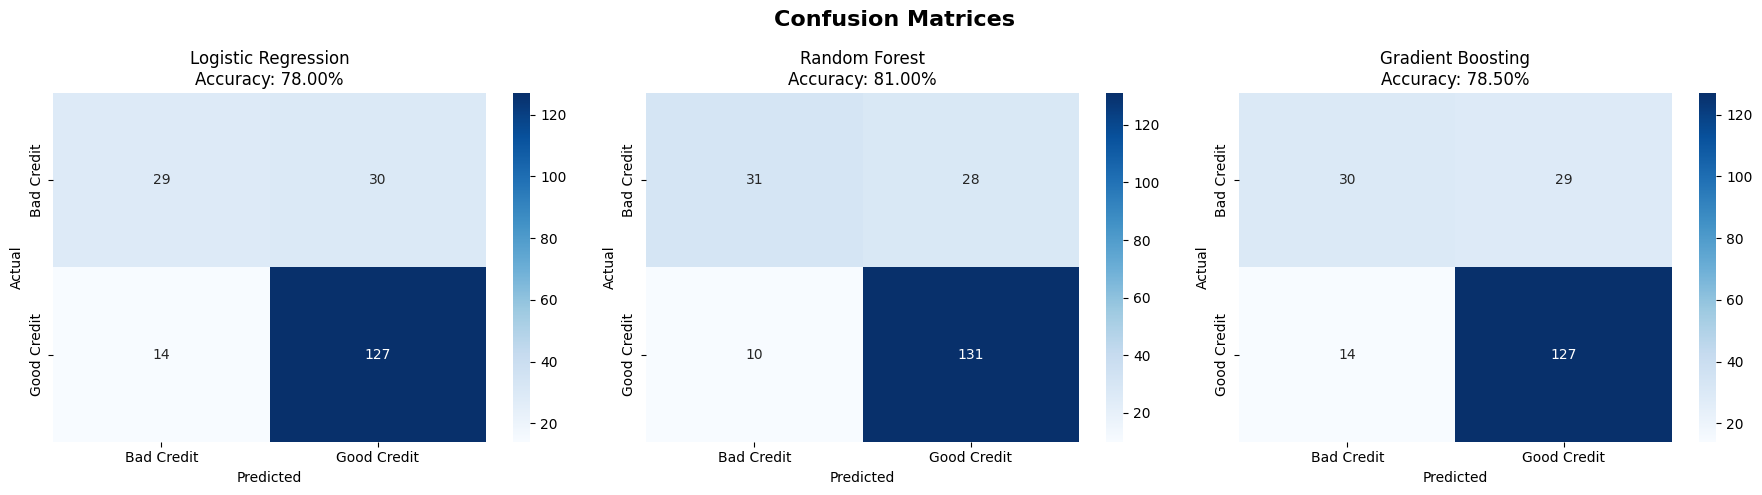

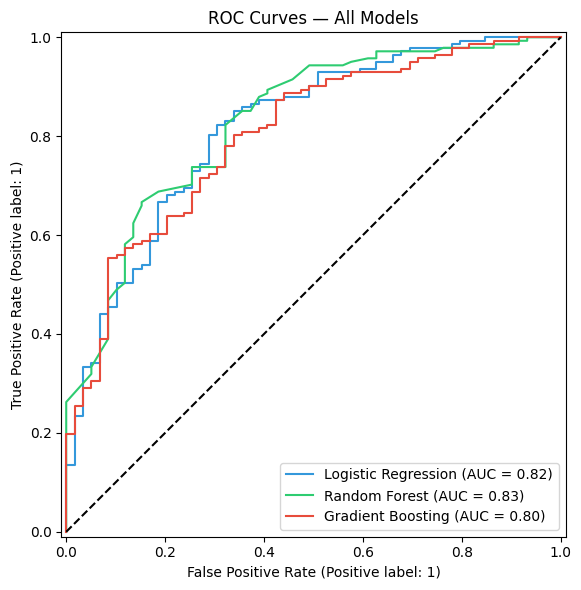

✅ Best model (Random Forest) saved!


In [10]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bad Credit','Good Credit'],
                yticklabels=['Bad Credit','Good Credit'],
                ax=axes[i])
    axes[i].set_title(f"{name}\nAccuracy: {r['accuracy']:.2%}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
for (name, r), color in zip(results.items(), colors):
    RocCurveDisplay.from_estimator(
        r['model'], X_test, y_test, name=name, color=color, ax=ax)
ax.set_title('ROC Curves — All Models')
ax.plot([0,1],[0,1],'k--', label='Random Guess')
plt.tight_layout()
plt.show()

# Save best model (Random Forest)
best_model = results['Random Forest']['model']
with open('credit_scoring_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('credit_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Best model (Random Forest) saved!")

✅ Dataset loaded: 1000 records, 21 features
✅ Data preprocessed!

Model                       Accuracy  Precision     Recall         F1    ROC-AUC
---------------------------------------------------------------------------
Logistic Regression           0.7800     0.8089     0.9007     0.8523     0.8170
Random Forest                 0.8100     0.8239     0.9291     0.8733     0.8291
Gradient Boosting             0.7850     0.8141     0.9007     0.8552     0.8037


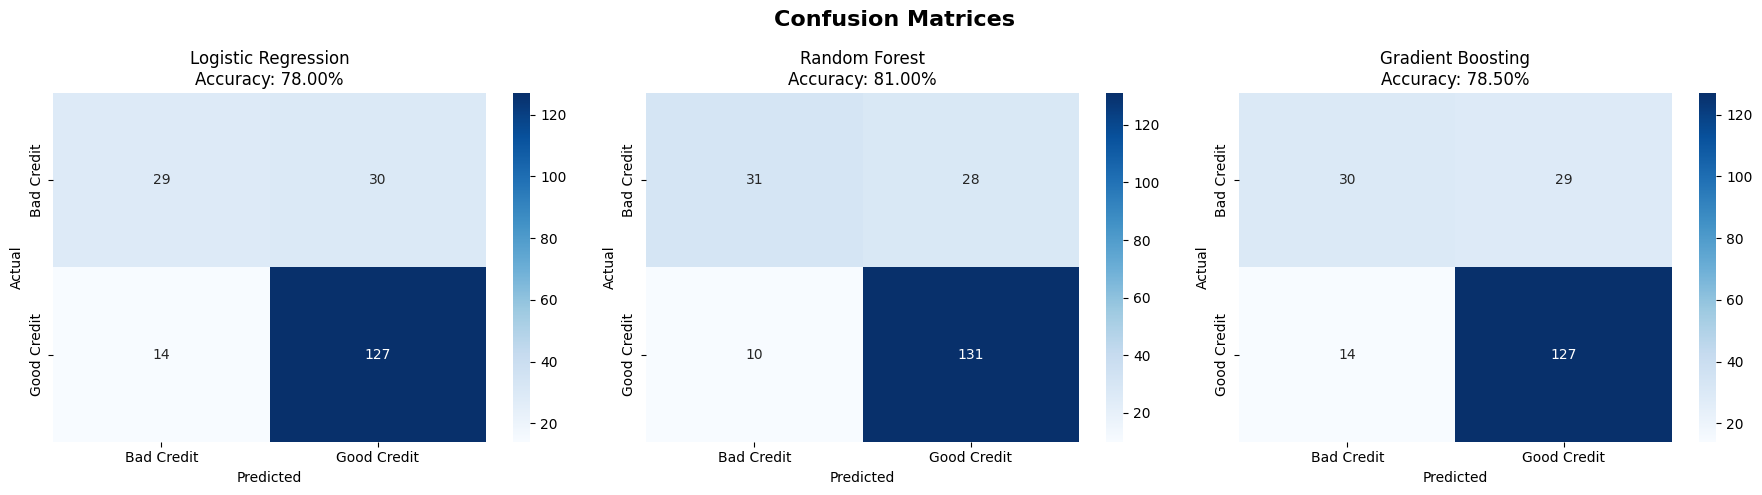

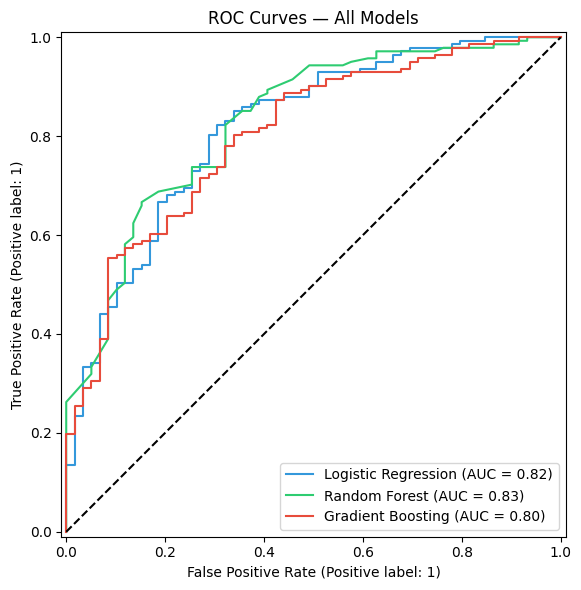


✅ Best model (Random Forest) saved!

   🏦 Credit Scoring Prediction Tool

Enter applicant details:
Account Status (0-3): 1
Loan Duration (months): 2
Credit History (0-4): 1
Purpose (0-9): 2
Loan Amount: 12222
Savings (0-4): 1
Employment Years (0-4): 1
Installment Rate (1-4): 1
Personal Status (0-3): 2
Other Debtors (0-2): 1
Residence Since (1-4): 2
Property (0-3): 1
Age: 21
Installment Plans (0-2): 1
Housing (0-2): 1
Existing Credits (1-4): 1
Job (0-3): 1
Dependents (1-2): 1
Telephone (0-1): 1
Foreign Worker (0-1): 1

===== 🏦 Credit Report =====
Result    : ❌ Bad Credit — Loan Rejected!
Confidence: 56.00%


In [13]:
# ============================================================
#   CREDIT SCORING MODEL
#   CodeAlpha Machine Learning Internship — Task 1
#   Author: Zeeshan Ahmad
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             RocCurveDisplay)

# ─── 1. LOAD DATA ───────────────────────────────────────────
try:
    url = "https://raw.githubusercontent.com/dsrscientist/Dataset1/master/german_credit_data.csv"
    df  = pd.read_csv(url)
except:
    url2 = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    columns = ['status','duration','credit_history','purpose','amount',
               'savings','employment','installment_rate','personal_status',
               'debtors','residence','property','age','installment_plans',
               'housing','existing_credits','job','dependents','telephone',
               'foreign_worker','target']
    df = pd.read_csv(url2, sep=' ', names=columns)

print(f"✅ Dataset loaded: {df.shape[0]} records, {df.shape[1]} features")

# ─── 2. PREPROCESS ──────────────────────────────────────────
df['target'] = df['target'].map({1: 1, 2: 0})

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("✅ Data preprocessed!")

# ─── 3. PREPARE DATA ────────────────────────────────────────
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ─── 4. TRAIN MODELS ────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        'model'    : model,
        'pred'     : pred,
        'accuracy' : accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall'   : recall_score(y_test, pred),
        'f1'       : f1_score(y_test, pred),
        'roc_auc'  : roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }

# ─── 5. COMPARE MODELS ──────────────────────────────────────
print("\n{:<25} {:>10} {:>10} {:>10} {:>10} {:>10}".format(
    'Model','Accuracy','Precision','Recall','F1','ROC-AUC'))
print("-" * 75)
for name, r in results.items():
    print("{:<25} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        name, r['accuracy'], r['precision'], r['recall'], r['f1'], r['roc_auc']))

# ─── 6. VISUALIZE ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bad Credit','Good Credit'],
                yticklabels=['Bad Credit','Good Credit'],
                ax=axes[i])
    axes[i].set_title(f"{name}\nAccuracy: {r['accuracy']:.2%}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

colors = ['#3498db', '#2ecc71', '#e74c3c']
fig, ax = plt.subplots(figsize=(8, 6))
for (name, r), color in zip(results.items(), colors):
    RocCurveDisplay.from_estimator(
        r['model'], X_test, y_test, name=name, color=color, ax=ax)
ax.set_title('ROC Curves — All Models')
ax.plot([0,1],[0,1],'k--', label='Random Guess')
plt.tight_layout()
plt.show()

# ─── 7. SAVE BEST MODEL ─────────────────────────────────────
best_model = results['Random Forest']['model']
with open('credit_scoring_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('credit_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Best model (Random Forest) saved!")

# ─── 8. USER INPUT PREDICTION ───────────────────────────────
print("\n" + "=" * 45)
print("   🏦 Credit Scoring Prediction Tool")
print("=" * 45)
print("\nEnter applicant details:")

status           = int(input("Account Status (0-3): "))
duration         = int(input("Loan Duration (months): "))
credit_history   = int(input("Credit History (0-4): "))
purpose          = int(input("Purpose (0-9): "))
amount           = int(input("Loan Amount: "))
savings          = int(input("Savings (0-4): "))
employment       = int(input("Employment Years (0-4): "))
installment_rate = int(input("Installment Rate (1-4): "))
personal_status  = int(input("Personal Status (0-3): "))
debtors          = int(input("Other Debtors (0-2): "))
residence        = int(input("Residence Since (1-4): "))
property         = int(input("Property (0-3): "))
age              = int(input("Age: "))
installment_plans= int(input("Installment Plans (0-2): "))
housing          = int(input("Housing (0-2): "))
existing_credits = int(input("Existing Credits (1-4): "))
job              = int(input("Job (0-3): "))
dependents       = int(input("Dependents (1-2): "))
telephone        = int(input("Telephone (0-1): "))
foreign_worker   = int(input("Foreign Worker (0-1): "))

user_data = pd.DataFrame([[status, duration, credit_history, purpose,
    amount, savings, employment, installment_rate, personal_status,
    debtors, residence, property, age, installment_plans, housing,
    existing_credits, job, dependents, telephone, foreign_worker]],
    columns=X.columns)

scaled_input = scaler.transform(user_data)
prediction   = best_model.predict(scaled_input)
probability  = best_model.predict_proba(scaled_input)

print("\n===== 🏦 Credit Report =====")
print(f"Result    : {'✅ Good Credit — Loan Approved!' if prediction[0]==1 else '❌ Bad Credit — Loan Rejected!'}")
print(f"Confidence: {max(probability[0])*100:.2f}%")
print("============================")

In [14]:
# ─── USER INPUT WITH OPTIONS ─────────────────────────────────
print("=" * 50)
print("   🏦 Credit Scoring Prediction Tool")
print("=" * 50)

# Account Status
print("\n📌 Account Status:")
print("  0 = No checking account")
print("  1 = < 0 DM (negative balance)")
print("  2 = 0-200 DM")
print("  3 = >= 200 DM")
status = int(input("Enter (0-3): "))

# Loan Duration
print("\n📌 Loan Duration:")
duration = int(input("Loan duration in months (e.g. 12, 24, 36): "))

# Credit History
print("\n📌 Credit History:")
print("  0 = No credits taken")
print("  1 = All credits paid back duly")
print("  2 = Existing credits paid back duly")
print("  3 = Delay in paying off in the past")
print("  4 = Critical account")
credit_history = int(input("Enter (0-4): "))

# Purpose
print("\n📌 Purpose of Loan:")
print("  0 = Car (new)")
print("  1 = Car (used)")
print("  2 = Furniture/equipment")
print("  3 = Radio/television")
print("  4 = Domestic appliances")
print("  5 = Repairs")
print("  6 = Education")
print("  7 = Vacation")
print("  8 = Retraining")
print("  9 = Business")
purpose = int(input("Enter (0-9): "))

# Loan Amount
print("\n📌 Loan Amount:")
amount = int(input("Enter amount in DM (e.g. 1000, 5000): "))

# Savings
print("\n📌 Savings Account:")
print("  0 = No savings account")
print("  1 = < 100 DM")
print("  2 = 100-500 DM")
print("  3 = 500-1000 DM")
print("  4 = >= 1000 DM")
savings = int(input("Enter (0-4): "))

# Employment
print("\n📌 Employment Since:")
print("  0 = Unemployed")
print("  1 = < 1 year")
print("  2 = 1-4 years")
print("  3 = 4-7 years")
print("  4 = >= 7 years")
employment = int(input("Enter (0-4): "))

# Installment Rate
print("\n📌 Installment Rate (% of income):")
print("  1 = >= 35%")
print("  2 = 25-35%")
print("  3 = 15-25%")
print("  4 = < 15%")
installment_rate = int(input("Enter (1-4): "))

# Personal Status
print("\n📌 Personal Status:")
print("  0 = Male: divorced/separated")
print("  1 = Female: divorced/separated/married")
print("  2 = Male: single")
print("  3 = Male: married/widowed")
personal_status = int(input("Enter (0-3): "))

# Other Debtors
print("\n📌 Other Debtors/Guarantors:")
print("  0 = None")
print("  1 = Co-applicant")
print("  2 = Guarantor")
debtors = int(input("Enter (0-2): "))

# Residence
print("\n📌 Present Residence Since (years):")
print("  1 = < 1 year")
print("  2 = 1-4 years")
print("  3 = 4-7 years")
print("  4 = >= 7 years")
residence = int(input("Enter (1-4): "))

# Property
print("\n📌 Property:")
print("  0 = No property")
print("  1 = Car or other")
print("  2 = Building society savings")
print("  3 = Real estate")
property = int(input("Enter (0-3): "))

# Age
print("\n📌 Age:")
age = int(input("Enter age: "))

# Installment Plans
print("\n📌 Other Installment Plans:")
print("  0 = Bank")
print("  1 = Stores")
print("  2 = None")
installment_plans = int(input("Enter (0-2): "))

# Housing
print("\n📌 Housing:")
print("  0 = For free")
print("  1 = Own")
print("  2 = Rent")
housing = int(input("Enter (0-2): "))

# Existing Credits
print("\n📌 Number of Existing Credits:")
existing_credits = int(input("Enter (1-4): "))

# Job
print("\n📌 Job:")
print("  0 = Unemployed/unskilled non-resident")
print("  1 = Unskilled resident")
print("  2 = Skilled employee")
print("  3 = Management/self-employed")
job = int(input("Enter (0-3): "))

# Dependents
print("\n📌 Number of Dependents:")
print("  1 = 3 or more")
print("  2 = 0 to 2")
dependents = int(input("Enter (1-2): "))

# Telephone
print("\n📌 Telephone:")
print("  0 = None")
print("  1 = Yes, registered")
telephone = int(input("Enter (0-1): "))

# Foreign Worker
print("\n📌 Foreign Worker:")
print("  0 = No")
print("  1 = Yes")
foreign_worker = int(input("Enter (0-1): "))

# ─── PREDICT ─────────────────────────────────────────────────
user_data = pd.DataFrame([[status, duration, credit_history, purpose,
    amount, savings, employment, installment_rate, personal_status,
    debtors, residence, property, age, installment_plans, housing,
    existing_credits, job, dependents, telephone, foreign_worker]],
    columns=X.columns)

scaled_input = scaler.transform(user_data)
prediction   = best_model.predict(scaled_input)
probability  = best_model.predict_proba(scaled_input)

print("\n" + "=" * 45)
print("        🏦 Credit Report")
print("=" * 45)
print(f"Result    : {'✅ Good Credit — Loan Approved!' if prediction[0]==1 else '❌ Bad Credit — Loan Rejected!'}")
print(f"Confidence: {max(probability[0])*100:.2f}%")
print("=" * 45)

   🏦 Credit Scoring Prediction Tool

📌 Account Status:
  0 = No checking account
  1 = < 0 DM (negative balance)
  2 = 0-200 DM
  3 = >= 200 DM
Enter (0-3): 2

📌 Loan Duration:
Loan duration in months (e.g. 12, 24, 36): 24

📌 Credit History:
  0 = No credits taken
  1 = All credits paid back duly
  2 = Existing credits paid back duly
  3 = Delay in paying off in the past
  4 = Critical account
Enter (0-4): 1

📌 Purpose of Loan:
  0 = Car (new)
  1 = Car (used)
  2 = Furniture/equipment
  3 = Radio/television
  4 = Domestic appliances
  5 = Repairs
  6 = Education
  7 = Vacation
  8 = Retraining
  9 = Business
Enter (0-9): 1

📌 Loan Amount:
Enter amount in DM (e.g. 1000, 5000): 22222

📌 Savings Account:
  0 = No savings account
  1 = < 100 DM
  2 = 100-500 DM
  3 = 500-1000 DM
  4 = >= 1000 DM
Enter (0-4): 0

📌 Employment Since:
  0 = Unemployed
  1 = < 1 year
  2 = 1-4 years
  3 = 4-7 years
  4 = >= 7 years
Enter (0-4): 2

📌 Installment Rate (% of income):
  1 = >= 35%
  2 = 25-35%
  3